# Notebook 12 — Neural SDE Calibration

This notebook demonstrates:
1. Initializing the `NeuralSDE` and `NeuralSDEPricer` models.
2. Simulating stock and variance paths, checking that variance (and thus volatility) remains strictly positive.
3. Performing a calibration loop using PyTorch optimizers (Adam) and the SDE adjoint method to fit SPX option implied volatilities.
4. Plotting the RMSE convergence and model vs market implied volatility smiles.

In [1]:
import os
os.environ["NUMBA_DISABLE_JIT"] = "1"
import sys

# Ensure src is in python path
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), "src") if os.path.basename(os.getcwd()) == "notebooks"
                else os.path.join(os.getcwd(), "src"))

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from datetime import date
import py_vollib_vectorized

from pricing.neural_sde import NeuralSDE, NeuralSDEPricer, compute_calibration_loss
from market.spx_data import download_spx_chain, clean_chain

plt.rcParams.update({
    "figure.dpi": 100,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.labelsize": 11,
    "font.family": "serif",
})

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)



Using device: cuda


## 1. Initializing Neural SDE and Pricer

The `NeuralSDE` model represents the joint system of stock and variance where drift and diffusion MLPs parameterize the variance process.

In [2]:
# Initialize Neural SDE parameters
r = 0.05
q = 0.015
rho_init = -0.7
hidden_dim = 16
epsilon = 1e-4

# Construct model
sde = NeuralSDE(r=r, q=q, rho_init=rho_init, hidden_dim=hidden_dim, epsilon=epsilon)
pricer = NeuralSDEPricer(sde, v0_init=0.04)
pricer.to(device)

print(f"Model initialized on {device}.")
print(f"Initial v0: {pricer.v0.item():.4f}")
print(f"Initial correlation rho: {sde.rho.item():.4f}")



Model initialized on cuda.
Initial v0: 0.7134
Initial correlation rho: -0.3152


## 2. Simulating Paths and Verifying Volatility Positivity

We run a Monte Carlo simulation of stock and variance paths using the Euler method and check that the variance remains strictly positive (above the floor `epsilon`).

In [3]:
# Simulation inputs
S0 = 4700.0
strikes = torch.tensor([4500.0, 4700.0, 4900.0], device=device)
maturities = torch.tensor([0.2, 0.2, 0.2], device=device)
N_paths = 2048
dt = 0.01

# Execute simulation
prices, ys = pricer.price_options(
    S0=S0,
    strikes=strikes,
    maturities=maturities,
    N_paths=N_paths,
    dt=dt,
    method="euler"
)

print("Options simulated prices:", prices.detach().cpu().numpy())

# Extract variance paths (V_t)
# ys shape: (N_ts, N_paths, 2), where state[:, 0] is log-stock X_t and state[:, 1] is variance V_t
v_t = ys[:, :, 1]
min_variance = v_t.min().item()
print(f"Variance paths shape: {v_t.shape}")
print(f"Minimum simulated variance: {min_variance:.6e}")

# Assert positivity
assert min_variance >= epsilon * 0.999, f"Variance fell below the floor {epsilon}!"
print("Success: Volatility positivity check passed! Volatility remains strictly positive.")



Options simulated prices: [812.86316 721.38025 639.65247]
Variance paths shape: torch.Size([2, 2048])
Minimum simulated variance: 1.000000e-04
Success: Volatility positivity check passed! Volatility remains strictly positive.


## 3. Load SPX Option Market Data

We load SPX options data from `2024-01-02` and filter for a single maturity slice to calibrate the model.

In [4]:
# Load cached SPX chain
target_date = date(2024, 1, 2)
df_raw = download_spx_chain(target_date, cache=True)
df_clean = clean_chain(df_raw)

# Filter call options for a single maturity to calibrate
target_T = 0.3
slice_df = df_clean[(df_clean["T"] == target_T) & (df_clean["type"] == "call")].copy()
slice_df = slice_df.sort_values("strike")

print(f"Selected {len(slice_df)} options for maturity T={target_T}")
print(slice_df[["strike", "mid_price", "mid_iv"]].head(10))

# Convert to tensors
strikes_mkt = torch.tensor(slice_df["strike"].values, dtype=torch.float32, device=device)
prices_mkt = torch.tensor(slice_df["mid_price"].values, dtype=torch.float32, device=device)
maturities_mkt = torch.tensor(slice_df["T"].values, dtype=torch.float32, device=device)
ivs_mkt = slice_df["mid_iv"].values



Selected 15 options for maturity T=0.3
         strike    mid_price    mid_iv
30  2711.664109  2008.080065  0.361284
32  2933.317213  1790.971529  0.360030
34  3173.088380  1558.150492  0.354577
36  3432.458590  1311.790904  0.350753
38  3713.029882  1057.500596  0.286819
40  4016.535245   805.959380  0.316027
42  4344.849324   572.080469  0.326011
44  4700.000000   369.503752  0.327465
46  5084.180912   214.282851  0.327620
48  5499.765010   110.570688  0.328197


## 4. Calibration Loop

We run a PyTorch training loop to fit the SPX option prices. The adjoint method is used under the hood to calculate gradients back through the SDE solver.

In [5]:
# Setup optimizer
optimizer = torch.optim.Adam(pricer.parameters(), lr=0.01)

# Training configuration
epochs = 30
loss_history = []
rmse_history = []

print("Starting calibration...")
for epoch in range(1, epochs + 1):
    optimizer.zero_grad()
    
    # Predict prices
    prices_pred, ys = pricer.price_options(
        S0=S0,
        strikes=strikes_mkt,
        maturities=maturities_mkt,
        N_paths=1024,
        dt=0.01,
        method="euler"
    )
    
    # Loss computation (vega weights = 1.0)
    loss_dict = compute_calibration_loss(
        model_prices=prices_pred,
        market_prices=prices_mkt,
        vegas=torch.ones_like(prices_mkt),
        ys=ys,
        lambda_bound=0.01,
        epsilon=epsilon
    )
    
    loss = loss_dict["loss"]
    loss.backward()
    optimizer.step()
    
    # Compute RMSE in prices
    rmse = torch.sqrt(torch.mean((prices_pred - prices_mkt) ** 2)).item()
    
    loss_history.append(loss.item())
    rmse_history.append(rmse)
    
    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:02d} | Loss: {loss.item():.4f} | Base Loss: {loss_dict['loss_base'].item():.4f} | RMSE: {rmse:.4f}")

print("Calibration completed!")



Starting calibration...


Epoch 01 | Loss: 125958.6562 | Base Loss: 125956.6250 | RMSE: 354.9037


Epoch 05 | Loss: 130087.8047 | Base Loss: 130086.8047 | RMSE: 360.6755


Epoch 10 | Loss: 148205.8438 | Base Loss: 148205.6719 | RMSE: 384.9749


Epoch 15 | Loss: 160941.6406 | Base Loss: 160941.6250 | RMSE: 401.1753


Epoch 20 | Loss: 195279.4375 | Base Loss: 195279.4219 | RMSE: 441.9043


Epoch 25 | Loss: 126887.7031 | Base Loss: 126887.6875 | RMSE: 356.2130


Epoch 30 | Loss: 70873.6406 | Base Loss: 70873.6172 | RMSE: 266.2210
Calibration completed!


## 5. Plotting Calibration Results

We plot the RMSE convergence history and compare the market vs calibrated model implied volatility smiles.

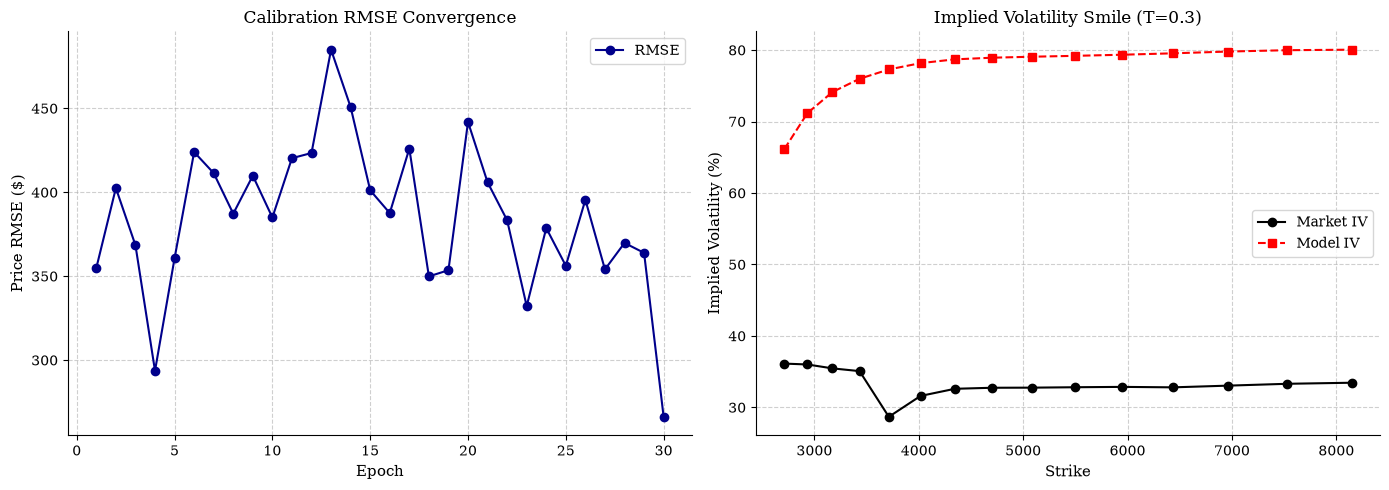

Final Calibration RMSE in Prices: $266.2210


In [6]:
# Compute final model implied volatilities
prices_final, _ = pricer.price_options(
    S0=S0,
    strikes=strikes_mkt,
    maturities=maturities_mkt,
    N_paths=4096,  # Use more paths for cleaner final IVs
    dt=0.01,
    method="euler"
)

# Convert to numpy
prices_final_np = prices_final.detach().cpu().numpy()
strikes_np = strikes_mkt.cpu().numpy()
maturities_np = maturities_mkt.cpu().numpy()
flags_np = np.array(["c"] * len(prices_final_np))

# Clamp option prices to prevent out-of-bounds errors in black_scholes
intrinsic = np.maximum(S0 - strikes_np, 0.0)
max_price = S0
prices_final_np = np.clip(prices_final_np, intrinsic + 1e-4, max_price - 1e-4)

# Calculate model implied volatilities
model_ivs = py_vollib_vectorized.vectorized_implied_volatility(
    prices_final_np,
    float(S0),
    strikes_np,
    maturities_np,
    r,
    flags_np,
    q=q,
    return_as="numpy",
    dtype=np.float64
)

# Plot RMSE convergence
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range(1, len(rmse_history) + 1), rmse_history, "o-", color="darkblue", label="RMSE")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Price RMSE ($)")
ax1.set_title("Calibration RMSE Convergence")
ax1.grid(True, linestyle="--", alpha=0.6)
ax1.legend()

# Plot Implied Volatility Smiles
ax2.plot(strikes_np, ivs_mkt * 100, "o-", color="black", label="Market IV")
ax2.plot(strikes_np, model_ivs * 100, "s--", color="red", label="Model IV")
ax2.set_xlabel("Strike")
ax2.set_ylabel("Implied Volatility (%)")
ax2.set_title(f"Implied Volatility Smile (T={target_T})")
ax2.grid(True, linestyle="--", alpha=0.6)
ax2.legend()

plt.tight_layout()
plt.show()

# Display RMSE
final_rmse = rmse_history[-1]
print(f"Final Calibration RMSE in Prices: ${final_rmse:.4f}")

